# Spatial Analysis of High-Risk Populations

This notebook continues the population-level biodiversity analysis from the previous notebooks.

The main unit of analysis is the **monitored population**, not the species.  
The risk categories are **not recalculated here**. They are loaded from the processed dataset created in `01_population_trend_calculation.ipynb`.

## Research questions

1. Where are high-risk vertebrate populations geographically located?
2. Which world regions contain the highest share of high-risk populations?
3. Which combinations of vertebrate class and region show the strongest risk patterns?
4. Are there spatial clusters where high-risk populations are especially concentrated?

## Consistent risk definition

Throughout this notebook, **high-risk populations** are defined as populations classified as:

- `Critical decline`
- `High decline`

This keeps the spatial analysis consistent with the trend and risk analysis notebooks.

In [1]:
# Import core libraries for data handling, plotting, and file paths.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set pandas display options to make tables easier to inspect in the notebook.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Define a consistent visual style for all figures in this notebook.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold"
})

# Define project paths relative to the notebook location.
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Create output folders if they do not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Define reusable colors for a consistent presentation style.
LAND_COLOR = "#F2F0EA"
BORDER_COLOR = "#C8C3B8"
ALL_POP_COLOR = "#2A7FB8"
HIGH_RISK_COLOR = "#C94C4C"
GRID_COLOR = "#E6E1D8"
TEXT_COLOR = "#333333"

# Load the population-level trend dataset created in notebook 01.
# This file should already contain Log_Trend, Risk_Category, and High_Risk.
DATA_PATH = PROCESSED_DIR / "lpd_population_trends_with_risk.csv"
trend_data = pd.read_csv(DATA_PATH)

# Print basic information to confirm that the correct file was loaded.
print("Loaded file:", DATA_PATH)
print("Dataset shape:", trend_data.shape)
print("Columns:")
print(trend_data.columns.tolist())


Loaded file: ../data/processed/lpd_population_trends_with_risk.csv
Dataset shape: (21284, 16)
Columns:
['ID', 'Binomial', 'Class', 'Region', 'System', 'Latitude', 'Longitude', 'First_Year', 'Last_Year', 'First_Population', 'Last_Population', 'Observations', 'Years_Monitored', 'Log_Trend', 'Risk_Category', 'High_Risk']


## 1. Validate required columns

Before doing spatial analysis, the notebook checks whether the required variables are present.  
This prevents silent errors later, especially if an older processed file was loaded by mistake.

In [2]:
# Define the columns that are required for the spatial risk analysis.
required_cols = [
    "ID",
    "Binomial",
    "Class",
    "Region",
    "System",
    "Latitude",
    "Longitude",
    "First_Year",
    "Last_Year",
    "Years_Monitored",
    "Log_Trend",
    "Risk_Category"
]

# Check whether any required columns are missing from the loaded dataset.
missing_cols = [col for col in required_cols if col not in trend_data.columns]

# Stop the notebook with a clear message if the processed dataset is incomplete.
if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}. "
        "Please rerun notebook 01 and make sure the file includes Risk_Category."
    )

# Show a compact preview of the key columns used in this notebook.
trend_data[required_cols].head()

,ID,Binomial,Class,Region,System,Latitude,Longitude,First_Year,Last_Year,Years_Monitored,Log_Trend,Risk_Category
0,1,Balearica_regulorum,Aves,Africa,Terrestrial,-0.07889,31.13306,1985,2002,17,0.920537,Increase
1,2,Acrocephalus_sechellensis,Aves,Africa,Terrestrial,-4.33333,55.66667,1958,1987,29,2.632121,Increase
2,3,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.66667,1977,1990,13,-0.572519,High decline
3,4,Copsychus_sechellarum,Aves,Africa,Terrestrial,-4.58333,55.93333,1976,1990,14,-0.714653,High decline
4,5,Falco_punctatus,Aves,Africa,Terrestrial,-20.30000,57.58333,1973,1997,24,3.433987,Increase


## 2. Prepare spatial data and reuse the same risk categories

The previous notebooks created the population-level risk categories.  
Here they are only checked, ordered, and converted into a simple `High_Risk` flag for maps and summaries.

In [3]:
# Define the same ordered risk categories used throughout the project.
risk_order = [
    "Critical decline",
    "High decline",
    "Moderate decline",
    "Stable / near stable",
    "Increase"
]

# Convert Risk_Category into an ordered categorical variable for consistent sorting and plotting.
trend_data["Risk_Category"] = pd.Categorical(
    trend_data["Risk_Category"],
    categories=risk_order,
    ordered=True
)

# Create or overwrite the High_Risk flag using the single project-wide definition.
trend_data["High_Risk"] = trend_data["Risk_Category"].isin(
    ["Critical decline", "High decline"]
)

# Convert coordinates to numeric values in case they were loaded as text.
trend_data["Latitude"] = pd.to_numeric(trend_data["Latitude"], errors="coerce")
trend_data["Longitude"] = pd.to_numeric(trend_data["Longitude"], errors="coerce")

# Keep only records with non-missing coordinates.
spatial_data = trend_data.dropna(subset=["Latitude", "Longitude"]).copy()

# Keep only records with valid latitude and longitude ranges.
spatial_data = spatial_data[
    spatial_data["Latitude"].between(-90, 90)
    & spatial_data["Longitude"].between(-180, 180)
].copy()

# Create a separate dataset for high-risk populations only.
high_risk_data = spatial_data[spatial_data["High_Risk"]].copy()

# Print checks to confirm that the spatial dataset and risk categories are ready.
print("Spatial dataset shape:", spatial_data.shape)
print("High-risk spatial dataset shape:", high_risk_data.shape)
print("\nRisk category counts:")
display(spatial_data["Risk_Category"].value_counts().reindex(risk_order))

Spatial dataset shape: (21284, 16)
High-risk spatial dataset shape: (6074, 16)

Risk category counts:


Risk_Category
Critical decline        4062
High decline            2012
Moderate decline        2790
Stable / near stable    5008
Increase                7412
Name: count, dtype: int64

## 3. Prepare a world basemap for spatial visualizations

The following maps use a lightweight Natural Earth land layer as a visual reference.  
This makes the spatial analysis easier to interpret for non-technical stakeholders, because the points are shown directly on a recognizable world map rather than on empty coordinate axes.

In [4]:
# Try to load optional geospatial libraries for a world basemap.
# If geopandas or geodatasets are unavailable, the notebook will still run with standard scatter plots.
try:
    import geopandas as gpd
    import geodatasets

    HAS_GEOPANDAS = True

    # Load a lightweight Natural Earth land basemap.
    world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

    # Convert the population dataset into a GeoDataFrame using WGS84 coordinates.
    gdf = gpd.GeoDataFrame(
        spatial_data,
        geometry=gpd.points_from_xy(
            spatial_data["Longitude"],
            spatial_data["Latitude"]
        ),
        crs="EPSG:4326"
    )

    # Create a GeoDataFrame for high-risk populations using the same High_Risk flag.
    high_risk_gdf = gdf[gdf["High_Risk"]].copy()

    print("Geopandas basemap setup successful.")
    print("World basemap features:", len(world))
    print("GeoDataFrame shape:", gdf.shape)

except Exception as error:
    HAS_GEOPANDAS = False
    world = None
    gdf = None
    high_risk_gdf = None

    # Print the error so the user knows why the notebook falls back to scatter plots.
    print("Geopandas basemap setup was skipped.")
    print("Reason:", error)

# Define a small helper function to format all world maps consistently.
def format_world_map(ax, title):
    """Apply consistent limits, title, and styling to world map figures."""
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=14, color=TEXT_COLOR)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)


Geopandas basemap setup successful.
World basemap features: 127
GeoDataFrame shape: (21284, 17)


### Interpretation checkpoint

At this point, the notebook has a clean spatial dataset and one consistent high-risk definition.  
All following maps and tables use `High_Risk == True`, not a new risk formula.

In [5]:
# Summarize coordinate coverage and the share of records available for spatial analysis.
total_populations = len(trend_data)
spatial_populations = len(spatial_data)
high_risk_populations = len(high_risk_data)

# Calculate simple coverage metrics for reporting.
spatial_coverage = spatial_populations / total_populations
high_risk_share_spatial = high_risk_populations / spatial_populations

# Display the main spatial coverage summary.
coverage_summary = pd.DataFrame({
    "Metric": [
        "Total monitored populations",
        "Populations with valid coordinates",
        "Spatial coverage share",
        "High-risk populations with valid coordinates",
        "High-risk share within spatial data"
    ],
    "Value": [
        total_populations,
        spatial_populations,
        round(spatial_coverage, 3),
        high_risk_populations,
        round(high_risk_share_spatial, 3)
    ]
})

coverage_summary

,Metric,Value
0,Total monitored populations,21284.000
1,Populations with valid coordinates,21284.000
2,Spatial coverage share,1.000
3,High-risk populations with valid coordinates,6074.000
4,High-risk share within spatial data,0.285


## 4. Global distribution of monitored populations

The first map shows the spatial coverage of all monitored populations.  
This is important because apparent high-risk clusters may partly reflect where monitoring data are available.

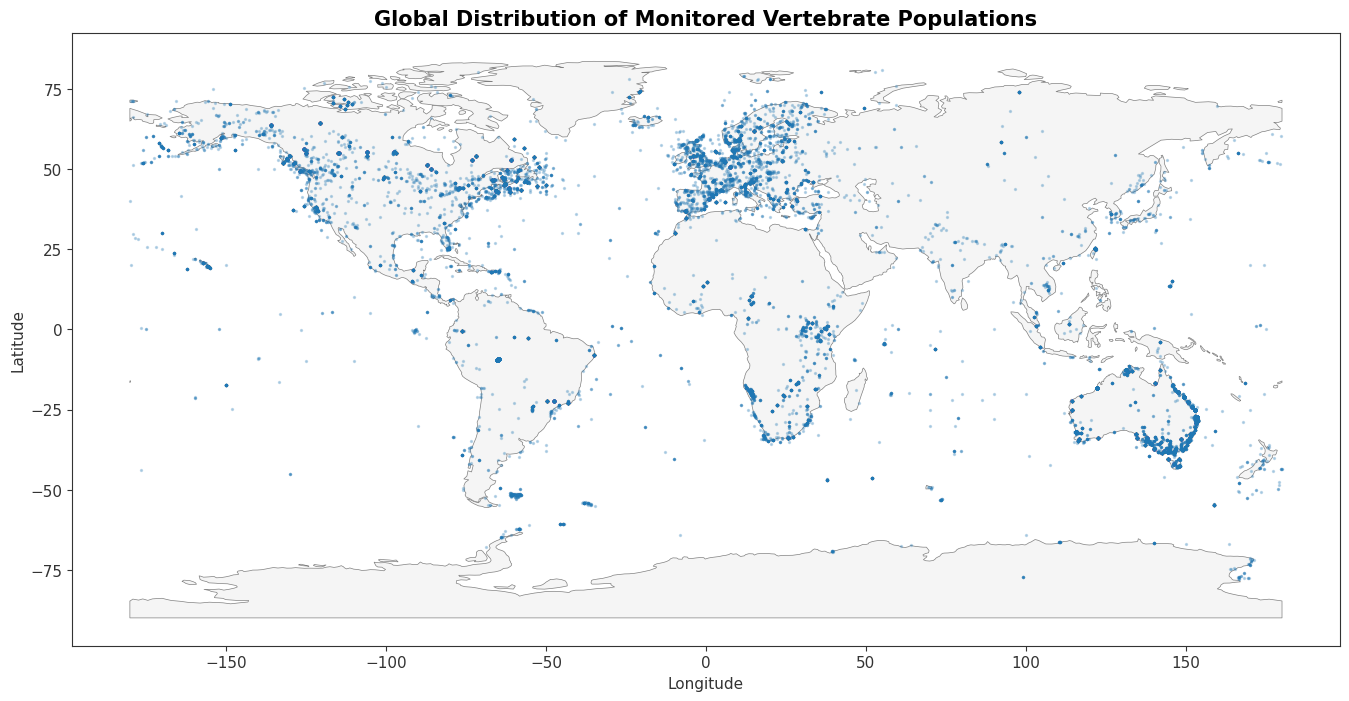

In [6]:
# Plot all monitored populations with valid coordinates as a simple global scatter plot.
fig, ax = plt.subplots(figsize=(14, 7))

world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="gray",
    linewidth=0.5
)

ax.scatter(
    spatial_data["Longitude"],
    spatial_data["Latitude"],
    s=2,
    alpha=0.25,
    color="#1f77b4"
)


ax.set_title(
    "Global Distribution of Monitored Vertebrate Populations",
    fontsize=16,
    pad=15
)

# Add titles and axis labels to make the plot interpretable.
plt.title("Global Distribution of Monitored Vertebrate Populations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Save the figure for the project outputs.
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_global_distribution_all_populations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Map high-risk populations

This map focuses only on high-risk populations.  
It answers the first spatial research question: **where are strongly declining monitored populations located?**

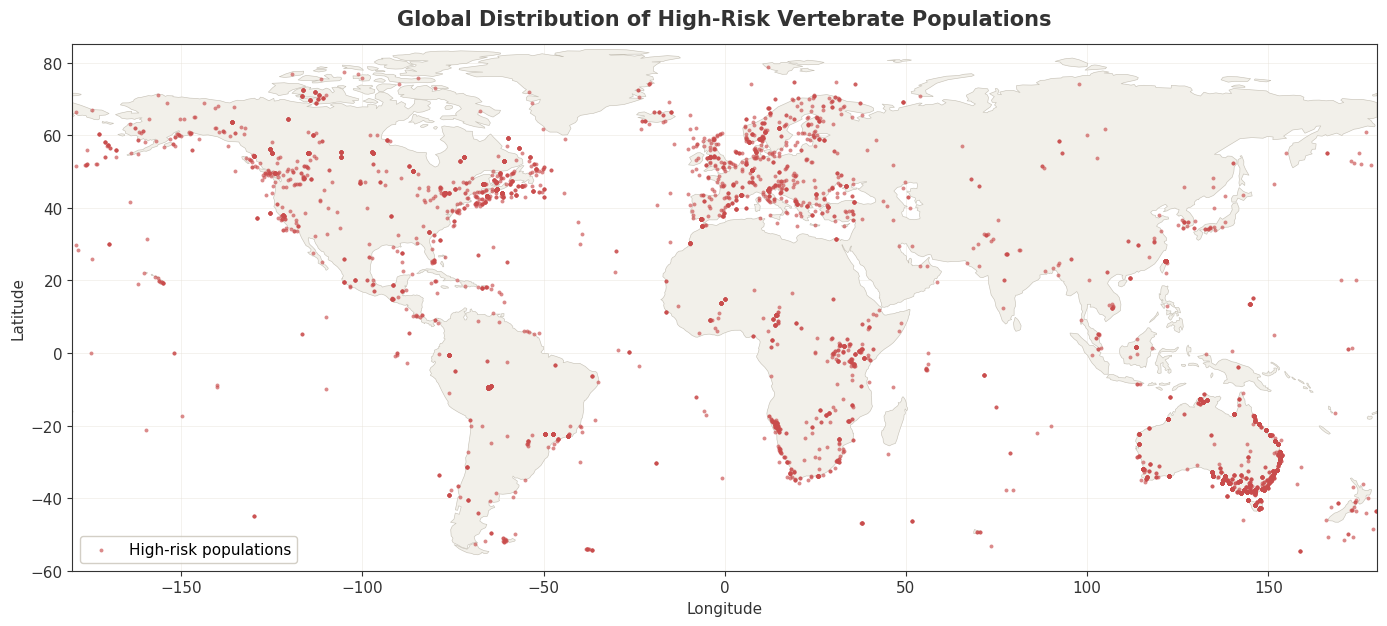

In [7]:
# Create a world map showing only high-risk populations.
fig, ax = plt.subplots(figsize=(14, 7))

# Draw the world basemap to make the spatial pattern interpretable.
if HAS_GEOPANDAS:
    world.plot(
        ax=ax,
        color=LAND_COLOR,
        edgecolor=BORDER_COLOR,
        linewidth=0.45,
        zorder=1
    )

# Plot high-risk populations using the same project-wide High_Risk flag.
ax.scatter(
    high_risk_data["Longitude"],
    high_risk_data["Latitude"],
    s=8,
    alpha=0.65,
    color=HIGH_RISK_COLOR,
    linewidths=0,
    zorder=2,
    label="High-risk populations"
)

# Apply consistent map formatting and title.
format_world_map(
    ax,
    "Global Distribution of High-Risk Vertebrate Populations"
)

# Add a simple legend for stakeholder readability.
ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor=BORDER_COLOR)

# Save and display the figure.
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_high_risk_population_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Compare high-risk populations with all monitored populations

This map is included to avoid over-interpreting raw high-risk locations.  
A region can show many high-risk points simply because it has many monitored populations overall.

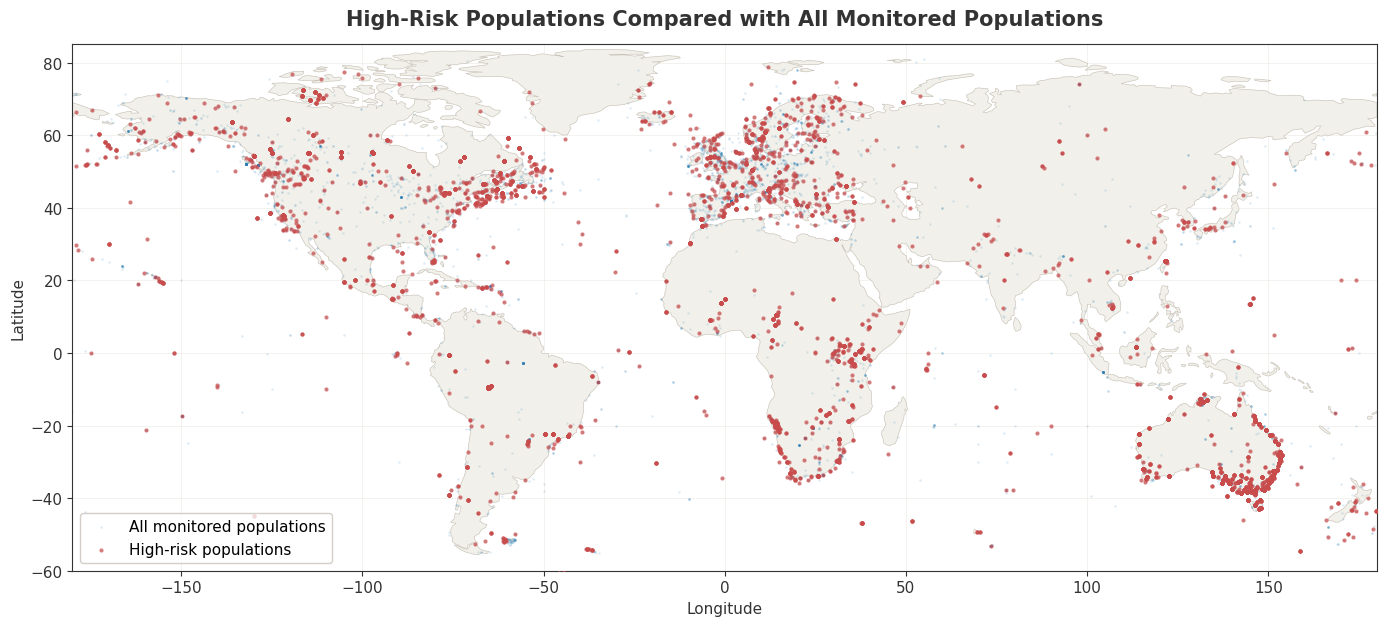

In [8]:
# Plot all monitored populations in the background and high-risk populations on top.
fig, ax = plt.subplots(figsize=(14, 7))

# Draw the world basemap first.
if HAS_GEOPANDAS:
    world.plot(
        ax=ax,
        color=LAND_COLOR,
        edgecolor=BORDER_COLOR,
        linewidth=0.45,
        zorder=1
    )

# Add all monitored populations as a faint background layer.
ax.scatter(
    spatial_data["Longitude"],
    spatial_data["Latitude"],
    s=3,
    alpha=0.16,
    color=ALL_POP_COLOR,
    linewidths=0,
    zorder=2,
    label="All monitored populations"
)

# Add high-risk populations as the main highlighted layer.
ax.scatter(
    high_risk_data["Longitude"],
    high_risk_data["Latitude"],
    s=9,
    alpha=0.72,
    color=HIGH_RISK_COLOR,
    linewidths=0,
    zorder=3,
    label="High-risk populations"
)

# Apply consistent map formatting and title.
format_world_map(
    ax,
    "High-Risk Populations Compared with All Monitored Populations"
)

# Add a legend that explains the two map layers.
ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor=BORDER_COLOR)

# Save and display the figure.
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_high_risk_vs_all_populations_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 7. Regional risk summary

Raw counts and proportions answer different questions:

- `High_Risk_Populations` shows where many high-risk monitored populations are located.
- `Risk_Share` shows the proportion of monitored populations in a region that are high-risk.

The share is more useful for comparing regions with different monitoring intensity.

In [9]:
# Count all monitored populations by region.
all_by_region = (
    spatial_data
    .groupby("Region", observed=True)
    .size()
    .reset_index(name="All_Populations")
)

# Count high-risk populations by region using the single High_Risk flag.
high_risk_by_region = (
    spatial_data[spatial_data["High_Risk"]]
    .groupby("Region", observed=True)
    .size()
    .reset_index(name="High_Risk_Populations")
)

# Merge total and high-risk counts into one regional summary table.
region_risk = (
    all_by_region
    .merge(
        high_risk_by_region,
        on="Region",
        how="left"
    )
)

# Replace missing high-risk counts with zero for regions without high-risk records.
region_risk["High_Risk_Populations"] = (
    region_risk["High_Risk_Populations"]
    .fillna(0)
    .astype(int)
)

# Calculate the high-risk share within each region.
region_risk["Risk_Share"] = (
    region_risk["High_Risk_Populations"]
    / region_risk["All_Populations"]
)

# Sort the table by risk share for interpretation.
region_risk = region_risk.sort_values(
    "Risk_Share",
    ascending=False
)

region_risk

,Region,All_Populations,High_Risk_Populations,Risk_Share
4,International Waters,154,63,0.409091
7,Oceania,6874,2706,0.393657
0,Africa,1577,543,0.344325
2,Asia,966,322,0.333333
1,Antarctic,202,47,0.232673
6,North America,5731,1228,0.214273
3,Europe,3648,753,0.206414
5,Latin America and Caribbean,2132,412,0.193246


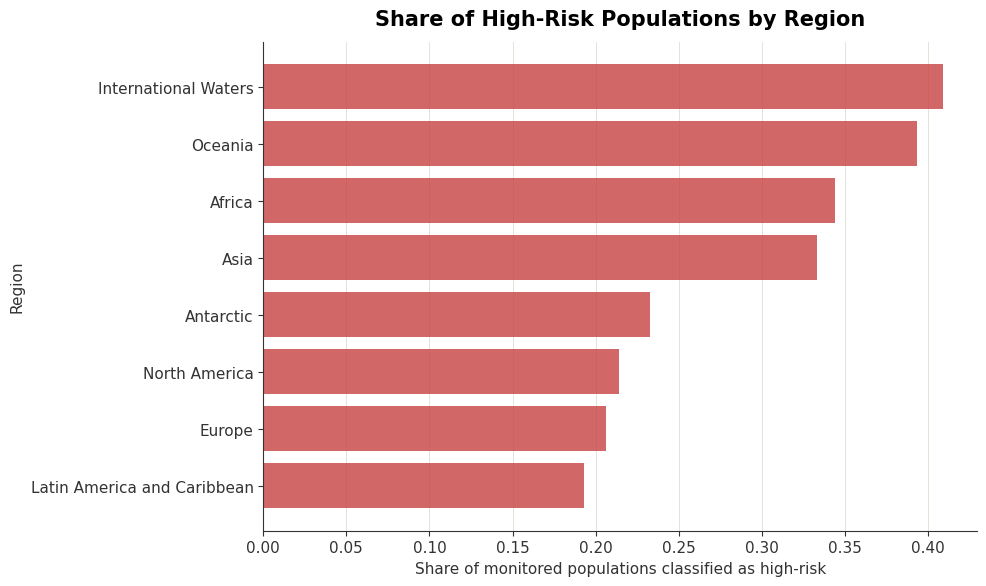

In [10]:
# Visualize the share of high-risk populations by region.
plot_data = region_risk.sort_values("Risk_Share", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Draw a horizontal bar chart using the same high-risk color used in the maps.
ax.barh(
    plot_data["Region"],
    plot_data["Risk_Share"],
    color=HIGH_RISK_COLOR,
    alpha=0.85
)

# Add labels and title.
ax.set_title("Share of High-Risk Populations by Region", pad=12)
ax.set_xlabel("Share of monitored populations classified as high-risk")
ax.set_ylabel("Region")

# Format the chart in the same clean style as the rest of the notebook.
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Save and display the plot.
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_high_risk_share_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Regional interpretation

This section should be interpreted as a **relative risk comparison**, not as a direct measure of total biodiversity loss.  
The Living Planet Database is based on monitored populations, so regional patterns may also reflect differences in monitoring coverage.

## 8. Class × region risk patterns

The next step combines taxonomy and geography.  
This addresses the question:

**Which vertebrate groups show the highest share of high-risk populations in each region?**

To avoid misleading results from very small sample sizes, the heatmap masks class-region combinations with fewer than 20 monitored populations.

In [11]:
# Create a table with all monitored population counts by class and region.
all_counts = pd.crosstab(
    spatial_data["Class"],
    spatial_data["Region"]
)

# Create a table with high-risk population counts by class and region.
risk_counts = pd.crosstab(
    high_risk_data["Class"],
    high_risk_data["Region"]
)

# Align risk_counts to all_counts so both tables have the same rows and columns.
risk_counts = risk_counts.reindex(
    index=all_counts.index,
    columns=all_counts.columns,
    fill_value=0
)

# Calculate the share of high-risk populations within each class-region combination.
risk_share_heatmap = risk_counts / all_counts

# Mask combinations with fewer than 20 monitored populations to reduce unstable comparisons.
min_populations = 20
risk_share_heatmap_filtered = risk_share_heatmap.where(all_counts >= min_populations)

# Display the filtered table before plotting.
risk_share_heatmap_filtered

Region,Africa,Antarctic,Asia,Europe,International Waters,Latin America and Caribbean,North America,Oceania
Class,,,,,,,,
Actinopteri,0.233696,NaN,0.402010,0.280269,0.466019,0.136558,0.227948,0.267943
Amphibia,NaN,NaN,0.785714,0.363636,NaN,0.465517,0.291139,NaN
Aves,0.334370,0.216667,0.333333,0.215116,NaN,0.279503,0.198054,0.408424
Dipneusti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Elasmobranchii,0.424242,NaN,NaN,0.173913,0.282609,0.181818,0.188285,0.222222
Holocephali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mammalia,0.379009,NaN,0.240000,0.119082,NaN,0.354167,0.231461,0.333333
Myxini,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Petromyzonti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


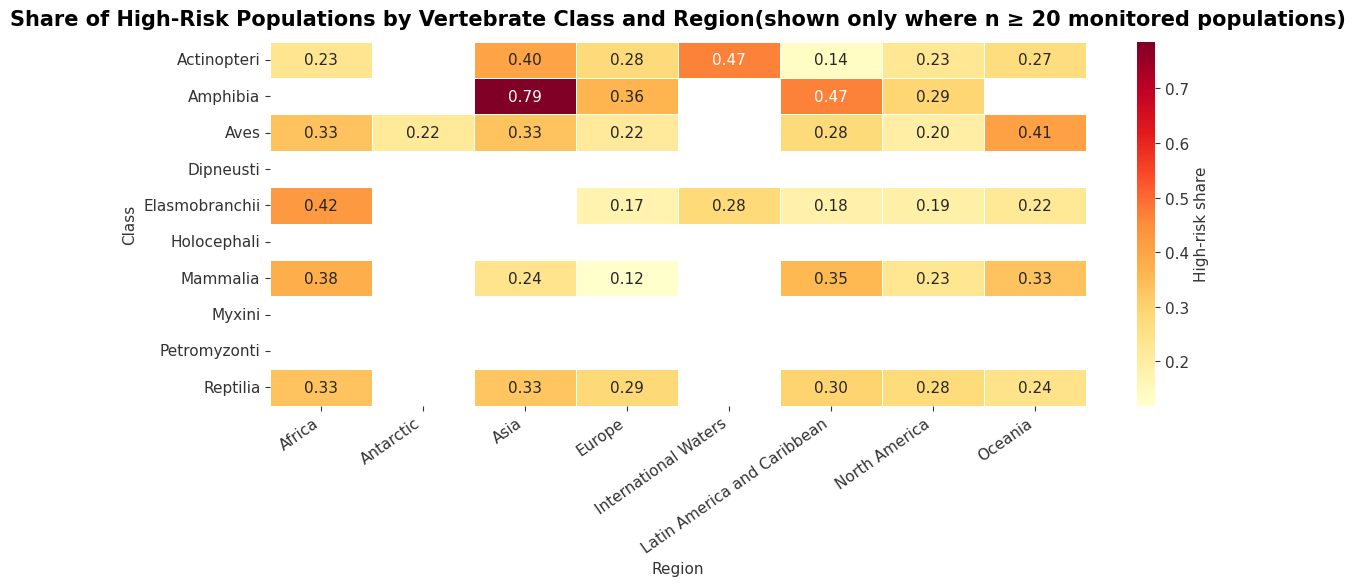

In [12]:
# Plot the class-region high-risk share heatmap.
# Seaborn is used only for visualization; the underlying values were calculated above.
try:
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.heatmap(
        risk_share_heatmap_filtered,
        cmap="YlOrRd",
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "High-risk share"},
        ax=ax
    )

    # Add a stakeholder-friendly title that explains the sample-size filter.
    ax.set_title(
        "Share of High-Risk Populations by Vertebrate Class and Region"
        f"(shown only where n ≥ {min_populations} monitored populations)",
        pad=12
    )
    ax.set_xlabel("Region")
    ax.set_ylabel("Class")

    # Rotate x-axis labels for readability.
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "03_class_region_high_risk_share_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

except Exception as error:
    # If seaborn is unavailable, show the numeric table instead of failing the notebook.
    print("Heatmap could not be plotted because seaborn is unavailable.")
    print("Reason:", error)
    display(risk_share_heatmap_filtered)


In [13]:
# Convert the class-region risk share matrix into a ranked summary table.
class_region_summary = (
    risk_share_heatmap_filtered
    .stack(dropna=True)
    .reset_index(name="High_Risk_Share")
)

# Add total monitored and high-risk counts for each class-region combination.
class_region_summary["All_Populations"] = class_region_summary.apply(
    lambda row: all_counts.loc[row["Class"], row["Region"]],
    axis=1
)

class_region_summary["High_Risk_Populations"] = class_region_summary.apply(
    lambda row: risk_counts.loc[row["Class"], row["Region"]],
    axis=1
)

# Sort by high-risk share first and high-risk count second.
class_region_summary = class_region_summary.sort_values(
    ["High_Risk_Share", "High_Risk_Populations"],
    ascending=[False, False]
)

# Show the strongest class-region risk patterns.
class_region_summary.head(20)

,Class,Region,High_Risk_Share,All_Populations,High_Risk_Populations
7,Amphibia,Asia,0.785714,28,22
3,Actinopteri,International Waters,0.466019,103,48
9,Amphibia,Latin America and Caribbean,0.465517,58,27
18,Elasmobranchii,Africa,0.424242,33,14
17,Aves,Oceania,0.408424,5793,2366
1,Actinopteri,Asia,0.402010,199,80
24,Mammalia,Africa,0.379009,686,260
8,Amphibia,Europe,0.363636,22,8
27,Mammalia,Latin America and Caribbean,0.354167,96,34
11,Aves,Africa,0.334370,643,215


## 9. Spatial hotspot grid

The final spatial step uses a simple 10-degree latitude/longitude grid.  
This is not a formal ecological hotspot model, but it provides a transparent exploratory view of where high-risk monitored populations cluster.

The grid summary includes:

- total monitored populations in each grid cell
- high-risk populations in each grid cell
- high-risk share in each grid cell

In [14]:
# Define the grid size in degrees.
grid_size = 10

# Assign each population to a latitude and longitude bin.
spatial_data["Lat_Bin"] = np.floor(spatial_data["Latitude"] / grid_size) * grid_size
spatial_data["Lon_Bin"] = np.floor(spatial_data["Longitude"] / grid_size) * grid_size

# Create a refreshed high-risk dataset after the grid columns have been added.
high_risk_data = spatial_data[spatial_data["High_Risk"]].copy()

# Count all monitored populations in each grid cell.
grid_all = (
    spatial_data
    .groupby(["Lat_Bin", "Lon_Bin"], observed=True)
    .size()
    .reset_index(name="All_Populations")
)

# Count high-risk populations in each grid cell.
grid_high_risk = (
    high_risk_data
    .groupby(["Lat_Bin", "Lon_Bin"], observed=True)
    .size()
    .reset_index(name="High_Risk_Populations")
)

# Merge all and high-risk counts into one hotspot table.
hotspots = (
    grid_all
    .merge(
        grid_high_risk,
        on=["Lat_Bin", "Lon_Bin"],
        how="left"
    )
)

# Fill missing high-risk counts with zero.
hotspots["High_Risk_Populations"] = (
    hotspots["High_Risk_Populations"]
    .fillna(0)
    .astype(int)
)

# Calculate the high-risk share in each grid cell.
hotspots["Risk_Share"] = (
    hotspots["High_Risk_Populations"]
    / hotspots["All_Populations"]
)

# Keep only grid cells with enough monitored populations for more stable comparison.
min_grid_populations = 20
hotspots_filtered = hotspots[
    hotspots["All_Populations"] >= min_grid_populations
].copy()

# Add grid cell centers for plotting.
hotspots_filtered["Lat_Center"] = hotspots_filtered["Lat_Bin"] + grid_size / 2
hotspots_filtered["Lon_Center"] = hotspots_filtered["Lon_Bin"] + grid_size / 2

# Show the strongest exploratory hotspot cells.
hotspots_filtered.sort_values(
    ["Risk_Share", "High_Risk_Populations"],
    ascending=[False, False]
).head(20)

,Lat_Bin,Lon_Bin,All_Populations,High_Risk_Populations,Risk_Share,Lat_Center,Lon_Center
150,0.0,110.0,31,24,0.774194,5.0,115.0
37,-40.0,-80.0,35,22,0.628571,-35.0,-75.0
165,10.0,-10.0,31,19,0.612903,15.0,-5.0
167,10.0,10.0,50,30,0.600000,15.0,15.0
63,-30.0,10.0,87,48,0.551724,-25.0,15.0
35,-50.0,170.0,32,16,0.500000,-45.0,175.0
51,-40.0,130.0,598,296,0.494983,-35.0,135.0
158,10.0,-100.0,46,22,0.478261,15.0,-95.0
4,-70.0,-60.0,21,10,0.476190,-65.0,-55.0
177,10.0,140.0,36,17,0.472222,15.0,145.0


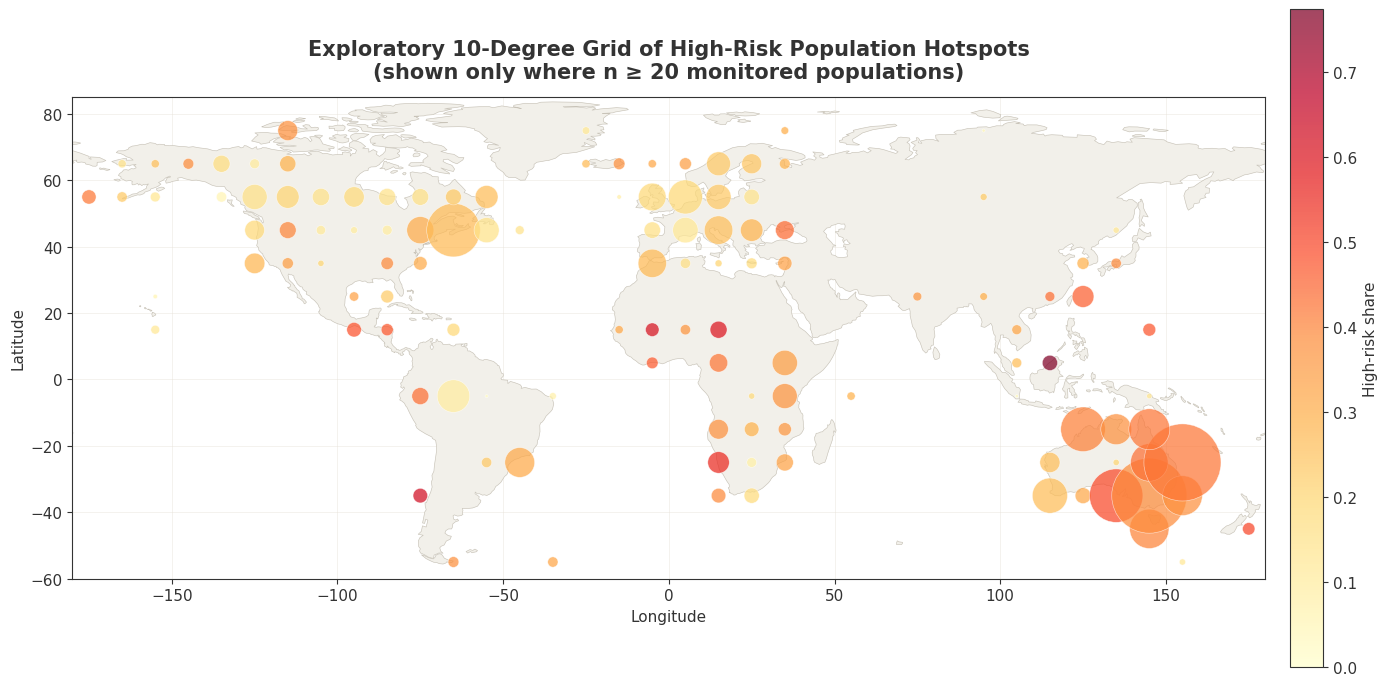

In [15]:
# Plot the exploratory hotspot grid on top of the world basemap.
fig, ax = plt.subplots(figsize=(14, 7))

# Draw the world map first so the hotspot bubbles have geographic context.
if HAS_GEOPANDAS:
    world.plot(
        ax=ax,
        color=LAND_COLOR,
        edgecolor=BORDER_COLOR,
        linewidth=0.45,
        zorder=1
    )

# Plot hotspot grid cells using point size for high-risk counts and color for high-risk share.
scatter = ax.scatter(
    hotspots_filtered["Lon_Center"],
    hotspots_filtered["Lat_Center"],
    s=hotspots_filtered["High_Risk_Populations"] * 5,
    c=hotspots_filtered["Risk_Share"],
    cmap="YlOrRd",
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    zorder=2
)

# Add a colorbar to show the high-risk share scale.
cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("High-risk share")

# Apply consistent map formatting and title.
format_world_map(
    ax,
    "Exploratory 10-Degree Grid of High-Risk Population Hotspots\n"
    f"(shown only where n ≥ {min_grid_populations} monitored populations)"
)

# Save and display the figure.
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_exploratory_high_risk_hotspot_grid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 10. Export spatial summary tables

The summary tables are saved so they can be reused in the README, presentation, or later analysis.

In [16]:
# Save regional risk summary for reporting.
region_risk.to_csv(
    OUTPUT_DIR / "03_region_high_risk_summary.csv",
    index=False
)

# Save class-region risk summary for reporting.
class_region_summary.to_csv(
    OUTPUT_DIR / "03_class_region_high_risk_summary.csv",
    index=False
)

# Save hotspot grid summary for reporting.
hotspots_filtered.to_csv(
    OUTPUT_DIR / "03_hotspot_grid_summary.csv",
    index=False
)

# Confirm that the files were saved.
print("Saved summary tables:")
print("-", OUTPUT_DIR / "03_region_high_risk_summary.csv")
print("-", OUTPUT_DIR / "03_class_region_high_risk_summary.csv")
print("-", OUTPUT_DIR / "03_hotspot_grid_summary.csv")

Saved summary tables:
- ../outputs/03_region_high_risk_summary.csv
- ../outputs/03_class_region_high_risk_summary.csv
- ../outputs/03_hotspot_grid_summary.csv


# Final interpretation

This notebook extends the population-level trend and risk analysis into a spatial context.

The main findings should be interpreted carefully:

1. The maps show where monitored high-risk populations are located.
2. Regional risk shares help compare regions while accounting for different numbers of monitored populations.
3. Class-region heatmaps identify combinations of animal group and region with especially high proportions of high-risk populations.
4. The grid hotspot analysis is exploratory and depends on monitoring coverage.

The spatial analysis therefore supports the overall project story:

**Population trends are calculated first, one consistent risk definition is applied, and then the spatial analysis asks where those high-risk populations are concentrated.**